In [ ]:
import numpy as np
from matplotlib import pyplot
import scipy

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ex3weights.mat to ex3weights.mat


In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Displays 2D data stored in X in a nice grid.
    """
    # Compute rows, cols
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promote to a 2 dimensional array
    else:
        raise IndexError('Input X should be 1 or 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Compute number of items to display
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(
        display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')


In [ ]:
data = scipy.io.loadmat('ex3data1.mat', squeeze_me=True)
X = data['X']
y = data['y']


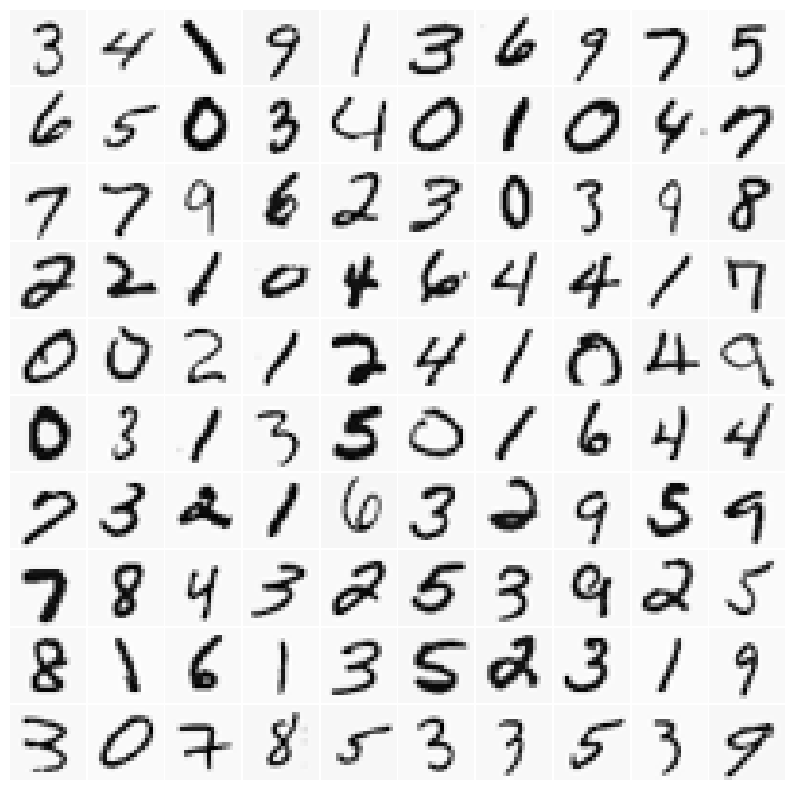

In [ ]:
rand_indices = np.random.choice(X.shape[0], 100, replace=False)
displayData(X[rand_indices, :])


In [ ]:
##Definimos funciones auxiliares que vamos a necesitar para entrenar nuestro modelo onevsall
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function_reg(theta, X, y, lambda_):
    h = sigmoid(np.dot(X, theta))
    reg_term = (lambda_ / (2 * len(y))) * np.sum(theta[1:] ** 2)
    J = (1 / len(y)) * (-np.dot(y, np.log(h)) - np.dot((1 - y), np.log(1 - h))) + reg_term
    return J

def gradient_reg(theta, X, y, lambda_):
    h = sigmoid(np.dot(X, theta))
    grad = (1 / len(y)) * np.dot((h - y), X)
    reg_term = (lambda_ / len(y)) * theta
    reg_term[0] = 0
    grad += reg_term
    return grad

def gradient_descent(X, y, theta, alpha, num_iters, lambda_):
    J_history = []
    for _ in range(num_iters):
        theta -= alpha * gradient_reg(theta, X, y, lambda_)
        J_history.append(cost_function_reg(theta, X, y, lambda_))

    return theta, J_history

In [22]:

def oneVsAll(X, y, n_labels, lambda_):
    """
     Trains n_labels logistic regression classifiers and returns
     each of these classifiers in a matrix all_theta, where the i-th
     row of all_theta corresponds to the classifier for label i.

     Parameters
     ----------
     X : array_like
         The input dataset of shape (m x n). m is the number of
         data points, and n is the number of features.

     y : array_like
         The data labels. A vector of shape (m, ).

     n_labels : int
         Number of possible labels.

     lambda_ : float
         The logistic regularization parameter.

     Returns
     -------
     all_theta : array_like
         The trained parameters for logistic regression for each class.
         This is a matrix of shape (K x n+1) where K is number of classes
         (ie. `n_labels`) and n is number of features without the bias.
     """
    m, n = np.shape(X)
    alpha = 0.3
    num_iters = 100000
    all_theta = np.zeros((n_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(n_labels):
        initial_theta = np.zeros(n + 1)
        y_label = (y == c).astype(int)
        theta, _ = gradient_descent(X, y_label, initial_theta, alpha, num_iters, lambda_)
        all_theta[c, :] = theta

    return all_theta


In [23]:
def predictOneVsAll(all_theta, X):
    """
    Return a vector of predictions for each example in the matrix X.
    Note that X contains the examples in rows. all_theta is a matrix where
    the i-th row is a trained logistic regression theta vector for the
    i-th class. You should set p to a vector of values from 0..K-1
    (e.g., p = [0, 2, 0, 1] predicts classes 0, 2, 0, 1 for 4 examples) .

    Parameters
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Returns
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """
    m = X.shape[0]
    X_bias = np.hstack([np.ones((m, 1)), X])
    prob = sigmoid(np.dot(X_bias, all_theta.T))
    p = np.argmax(prob, axis=1)


    return p


In [ ]:
##entrenamos el modelo
data = scipy.io.loadmat('ex3data1.mat', squeeze_me=True)
X_train = data['X']
y_train = data['y']

theta = oneVsAll(X_train, y_train, 10, 0.1)
predictions = predictOneVsAll(theta, X_train)

accuracy = np.mean(predictions == y_train) * 100
print("Precisión en el conjunto de entrenamiento: " + str(accuracy))

In [ ]:
def predict(theta1, theta2, X):
    """
    Predict the label of an input given a trained neural network.

    Parameters
    ----------
    theta1 : array_like
        Weights for the first layer in the neural network.
        It has shape (2nd hidden layer size x input size).

    theta2: array_like
        Weights for the second layer in the neural network.
        It has shape (output layer size x 2nd hidden layer size).

    X : array_like
        The image inputs having shape (number of examples x image dimensions).

    Returns
    -------
    p : array_like
        Predictions vector containing the predicted label for each example.
        It has a length equal to the number of examples.
    """
    m = X.shape[0]
    X_bias = np.hstack([np.ones((m, 1)), X])

    z2 = np.dot(X_bias, theta1.T)
    a2 = sigmoid(z2)
    a2_bias = np.hstack([np.ones((m, 1)), a2])

    z3 = np.dot(a2_bias, theta2.T)
    a3 = sigmoid(z3)

    p = np.argmax(a3, axis=1)

    return p


In [ ]:
weights = scipy.io.loadmat('ex3weights.mat')
theta1, theta2 = weights['Theta1'], weights['Theta2']
data = scipy.io.loadmat('ex3data1.mat', squeeze_me=True)
X_train = data['X']
y_train = data['y']

p = predict(theta1, theta2, X_train)
accuracy = np.mean(p == y_train) * 100
print("Precisión en el conjunto de entrenamiento: " + str(accuracy))

Precisión en el conjunto de entrenamiento: 97.52
